In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정 (그래프 예쁘게 그리기)
sns.set_theme(style="whitegrid")

# 1. 데이터 로드 (경로는 본인 폴더 구조에 맞게 수정)
# 보통 data/hosp/ 안에 파일들이 있습니다.
patients = pd.read_csv('../data/hosp/patients.csv.gz')
admissions = pd.read_csv('../data/hosp/admissions.csv.gz')

# 2. 데이터 잘 불러왔는지 확인
print("Patients shape:", patients.shape)
print("Admissions shape:", admissions.shape)
display(patients.head())

Patients shape: (100, 6)
Admissions shape: (275, 16)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [3]:
# 3. 환자 정보와 입원 기록 합치기 (Inner Join)
# subject_id를 기준으로 두 테이블을 연결합니다.
df = pd.merge(admissions, patients, on='subject_id')

# '입원 시간'과 '퇴원 시간'을 문자열 -> 날짜(datetime) 형식으로 변환
df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])

# 변환 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            275 non-null    int64         
 1   hadm_id               275 non-null    int64         
 2   admittime             275 non-null    datetime64[ns]
 3   dischtime             275 non-null    datetime64[ns]
 4   deathtime             15 non-null     object        
 5   admission_type        275 non-null    object        
 6   admit_provider_id     275 non-null    object        
 7   admission_location    275 non-null    object        
 8   discharge_location    233 non-null    object        
 9   insurance             275 non-null    object        
 10  language              275 non-null    object        
 11  marital_status        263 non-null    object        
 12  race                  275 non-null    object        
 13  edregtime           

전체 입원 건수: 275
사망 건수: 15
원내 사망률: 5.45%


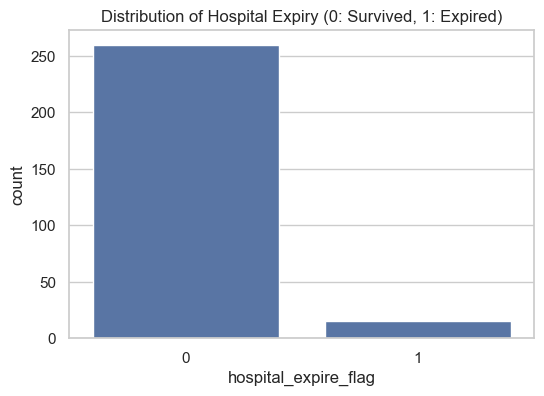

In [4]:
# 4. 사망률 계산
mortality_count = df['hospital_expire_flag'].value_counts()
mortality_rate = df['hospital_expire_flag'].mean() * 100

print(f"전체 입원 건수: {len(df)}")
print(f"사망 건수: {mortality_count.get(1, 0)}") # 1이 없으면 0 반환
print(f"원내 사망률: {mortality_rate:.2f}%")

# 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x='hospital_expire_flag', data=df)
plt.title('Distribution of Hospital Expiry (0: Survived, 1: Expired)')
plt.show()

평균 재원 기간: 6.88일
최대 재원 기간: 44.93일


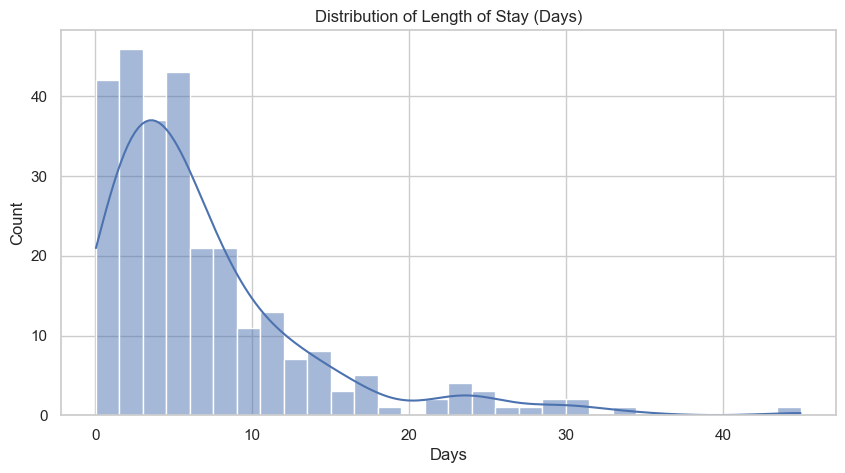

In [5]:
# 5. 재원 기간(LOS) 계산 (퇴원 시간 - 입원 시간)
df['los_days'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / (24 * 60 * 60)

print(f"평균 재원 기간: {df['los_days'].mean():.2f}일")
print(f"최대 재원 기간: {df['los_days'].max():.2f}일")

# 히스토그램 그리기
plt.figure(figsize=(10, 5))
sns.histplot(df['los_days'], bins=30, kde=True)
plt.title('Distribution of Length of Stay (Days)')
plt.xlabel('Days')
plt.show()

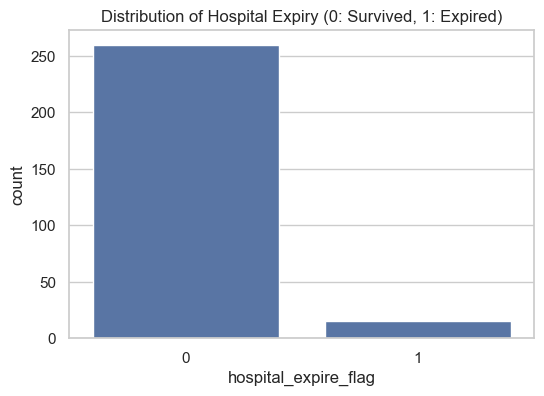

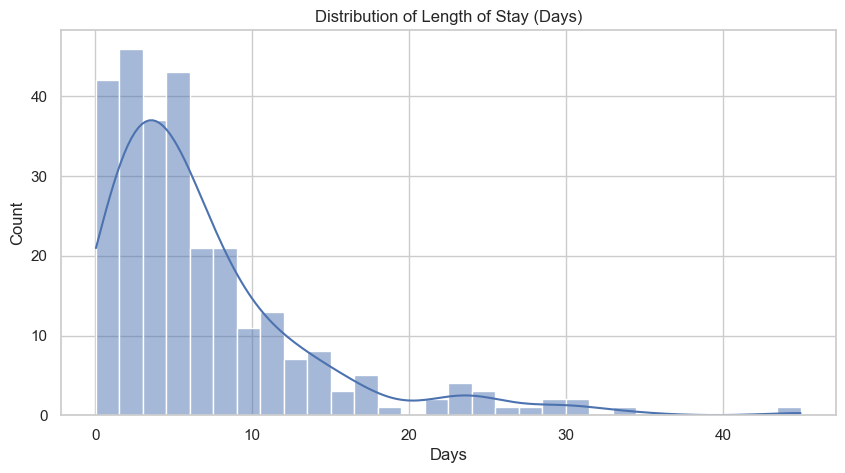

이미지 저장 완료! images 폴더를 확인해보세요.


In [6]:
import os

# 1. 이미지를 저장할 폴더 만들기 (없으면 생성)
os.makedirs('images', exist_ok=True)

# --- 첫 번째 그래프: 사망률 ---
plt.figure(figsize=(6, 4))
sns.countplot(x='hospital_expire_flag', data=df)
plt.title('Distribution of Hospital Expiry (0: Survived, 1: Expired)')

# [중요] plt.show() 하기 전에 저장해야 합니다!
plt.savefig('images/mortality_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 두 번째 그래프: 재원 기간(LOS) ---
plt.figure(figsize=(10, 5))
sns.histplot(df['los_days'], bins=30, kde=True)
plt.title('Distribution of Length of Stay (Days)')
plt.xlabel('Days')

# 저장하기
plt.savefig('images/los_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("이미지 저장 완료! images 폴더를 확인해보세요.")